- Supervised learning: Input & Output
- Unsupervised learning: Input

## Simple linear Regression

In [4]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['Target'] = data.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
X = df[['MedInc']]
y = df['Target']

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
linear = LinearRegression()

model = linear.fit(X_train,y_train)

In [ ]:
model.coef_ #slope

array([0.41933849])

In [ ]:
model.intercept_

0.44459729169078677

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import r2_score

print(r2_score(y_test,y_pred))

0.45885918903846656


In [17]:
y_pred

array([1.14958917, 1.50606882, 1.90393718, ..., 4.31500772, 1.612455  ,
       1.93412956])

In [19]:
y_pred = model.coef_ * X_test + model.intercept_

In [21]:
y_pred_train = model.predict(X_train)

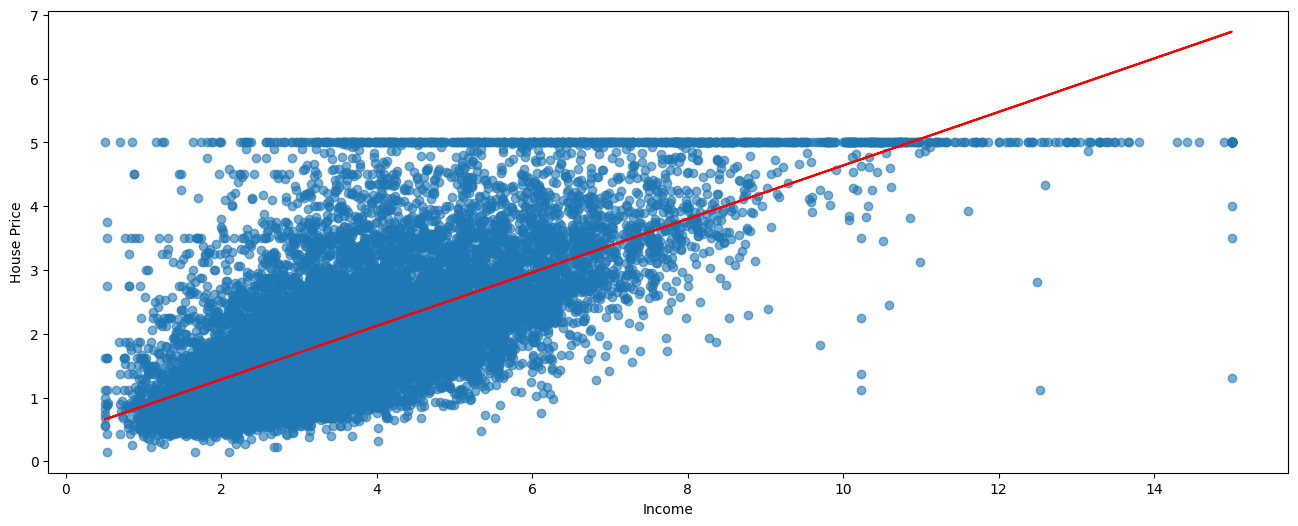

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.scatter(X_train,y_train,alpha=0.6)
plt.plot(X_train,y_pred_train,color="red")

plt.xlabel("Income")
plt.ylabel("House Price")
plt.show()


## Multiple Linear Regression

In [26]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [27]:
X = df.drop('Target',axis=1)
y = df['Target']

In [28]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [29]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Target, Length: 20640, dtype: float64

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
m = model.coef_

In [37]:
c = model.intercept_

In [34]:
y_pred = model.predict(X_test)

In [35]:
print(r2_score(y_test,y_pred))

0.575787706032451


In [38]:
m[0]

0.44867490966571827

In [39]:
m[7]

-0.43370806496398684

In [43]:
X_test.iloc[:,0]

20046    1.6812
3024     2.5313
15663    3.4801
20484    5.7376
9814     3.7250
          ...  
15362    4.6050
16623    2.7266
18086    9.2298
2144     2.7850
3665     3.5521
Name: MedInc, Length: 4128, dtype: float64

In [46]:
y_prd = c + m[0]*X_test.iloc[:,0] +m[1]*X_test.iloc[:,1] +m[2]*X_test.iloc[:,2] +m[3]*X_test.iloc[:,3] +m[4]*X_test.iloc[:,4] +m[5]*X_test.iloc[:,5] +m[6]*X_test.iloc[:,6] +m[7]*X_test.iloc[:,7] 

In [48]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [47]:
y_prd

20046    0.719123
3024     1.764017
15663    2.709659
20484    2.838926
9814     2.604657
           ...   
15362    1.991746
16623    2.249839
18086    4.468770
2144     1.187511
3665     2.009403
Length: 4128, dtype: float64